<a href="https://colab.research.google.com/github/tcplasma/TW50_Quant_Screener/blob/main/TW50_Quant_Screener.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔍 台股前50大權值股 量化因子選股系統
# 🔍 TW50 Multi-Layer Quantitative Stock Screener

---

> **投資哲學 | Investment Philosophy**
>
> **好公司 (Quality) × 好價格 (Value) × 好時機 (Momentum) = 超額報酬**
>
> **Quality Company × Right Price × Right Timing = Alpha Returns**

---

| 指標 Metric | 金融意義 Financial Meaning |
|---|---|
| **P/E 本益比** | 你付多少錢買 1 元盈餘 / Price paid per $1 of earnings |
| **P/B 本淨比** | 市值相對帳面價值 / Market value vs. book value |
| **殖利率 Dividend Yield** | 年度現金回報率 / Annual cash return rate |
| **ROE 股東權益報酬率** | 用股東資金賺錢的效率 / Efficiency of generating profit from equity |
| **營業利益率 Operating Margin** | 本業真實獲利能力 / Core business profitability |
| **MA20 穿越 MA20 Cross** | 短期趨勢轉折訊號 / Short-term trend reversal signal |
| **量能激增比 Volume Surge Ratio** | 資金積極介入程度 / Degree of capital inflow |

---

⚠️ **免責聲明 Disclaimer**：本筆記本為量化研究工具，不構成投資建議。本分析資料來自 Yahoo Finance，可能存在延遲或誤差，投資前請自行進行完整研究。  
This notebook is for quantitative research purposes only and does not constitute investment advice. Data sourced from Yahoo Finance may be delayed or inaccurate. Always conduct your own due diligence before investing.


## 📦 Step 1: 安裝套件與載入模組 | Install Packages & Import Libraries

**中文說明：** 安裝本系統所需的 Python 套件。  
**English:** Install all required Python packages for this system.

In [ ]:
# ── 安裝必要套件 | Install required packages ──────────────────────
!pip install yfinance pandas numpy matplotlib -q

# ── 載入標準函式庫 | Import standard libraries ────────────────────
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import warnings
import time
from datetime import datetime, timedelta
from IPython.display import display, HTML

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:.2f}'.format)

print("✅ 所有套件載入完成 | All packages loaded successfully")
print(f"📅 分析時間 Analysis time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")


✅ 所有套件載入完成 | All packages loaded successfully
📅 分析時間 Analysis time: 2026-04-02 04:01:56


## 📋 Step 2: 台灣50成分股清單 | TW50 Component List

**中文說明：**  
台股代號在 Yahoo Finance 需加上 `.TW` 後綴。  
此清單每季度（3/6/9/12月）由台灣證交所調整，請定期更新。  
參考來源：https://www.twse.com.tw

**English:**  
Taiwan stock tickers require a `.TW` suffix on Yahoo Finance.  
This list is updated quarterly (Mar/Jun/Sep/Dec) by the TWSE. Please refresh periodically.  
Reference: https://www.twse.com.tw


In [ ]:
# ── 台灣50成分股 | TW50 Components ──────────────────────────────────
# 格式 Format: "代號.TW": "中文名稱 / English Name"
# 更新日期 Last updated: 2025 Q1

TW50_COMPONENTS = {
    "2330.TW": "台積電 / TSMC",
    "2317.TW": "鴻海 / Hon Hai",
    "2454.TW": "聯發科 / MediaTek",
    "2308.TW": "台達電 / Delta Electronics",
    "2881.TW": "富邦金 / Fubon Financial",
    "2882.TW": "國泰金 / Cathay Financial",
    "2412.TW": "中華電 / Chunghwa Telecom",
    "2303.TW": "聯電 / UMC",
    "3711.TW": "日月光投控 / ASE Technology",
    "2002.TW": "中鋼 / China Steel",
    "1301.TW": "台塑 / Formosa Plastics",
    "1303.TW": "南亞 / Nan Ya Plastics",
    "2886.TW": "兆豐金 / Mega Financial",
    "2891.TW": "中信金 / CTBC Financial",
    "1326.TW": "台化 / Formosa Chemicals",
    "2884.TW": "玉山金 / E.Sun Financial",
    "2892.TW": "第一金 / First Financial",
    "5880.TW": "合庫金 / Taiwan Cooperative Financial",
    "2883.TW": "開發金 / CDIB Capital",
    "2885.TW": "元大金 / Yuanta Financial",
    "2890.TW": "永豐金 / SinoPac Financial",
    "6505.TW": "台塑化 / Formosa Petrochem",
    "3008.TW": "大立光 / Largan Precision",
    "2207.TW": "和泰車 / Hotai Motor",
    "2880.TW": "華南金 / Hua Nan Financial",
    "1216.TW": "統一 / Uni-President",
    "2382.TW": "廣達 / Quanta Computer",
    "4938.TW": "和碩 / Pegatron",
    "2395.TW": "研華 / Advantech",
    "2379.TW": "瑞昱 / Realtek",
    "2345.TW": "智邦 / Accton Technology",
    "2357.TW": "華碩 / ASUS",
    "2327.TW": "國巨 / Yageo",
    "3045.TW": "台灣大 / Taiwan Mobile",
    "4904.TW": "遠傳 / FarEasTone",
    "2912.TW": "統一超 / PX Mart",
    "1101.TW": "台泥 / Taiwan Cement",
    "2354.TW": "鴻準 / Foxconn Precision",
    "2377.TW": "微星 / MSI",
    "2408.TW": "南亞科 / Nanya Technology",
    "2301.TW": "光寶科 / Lite-On Technology",
    "6669.TW": "緯穎 / Wiwynn",
    "3034.TW": "聯詠 / Novatek",
    "2603.TW": "長榮 / Evergreen Marine",
    "2609.TW": "陽明 / Yang Ming Marine",
    "2615.TW": "萬海 / Wan Hai Lines",
    "1590.TW": "亞德客 / AirTAC",
    "8046.TW": "南電 / Nan Ya PCB",
}

print(f"📊 成分股總數 Total components: {len(TW50_COMPONENTS)} 檔")
print("✅ 清單載入完成 | Component list loaded")


📊 成分股總數 Total components: 48 檔
✅ 清單載入完成 | Component list loaded


## 🔧 Step 3: 數據抓取引擎 | Data Fetching Engine

**中文說明：**  
此模組透過 `yfinance` 自動抓取每檔股票的歷史 K 線與基本面數據，  
並計算所有量化因子。內建完整的錯誤處理機制：  
- 停牌或下市股票 → 自動跳過  
- API 速率限制 → 自動暫停後重試  
- 缺失欄位 → 以 `NaN` 填補，不影響其他計算

**English:**  
This module uses `yfinance` to automatically fetch historical OHLCV data and fundamentals  
for each stock, then computes all quantitative factors. Built-in error handling covers:  
- Suspended/delisted stocks → auto-skip  
- API rate limits → auto-pause and retry  
- Missing fields → filled with `NaN`, no impact on other calculations


In [ ]:
def fetch_stock_data(ticker: str, name: str, period_years: int = 5):
    """
    抓取單一股票完整量化數據 | Fetch complete quantitative data for a single stock.

    Parameters 參數:
        ticker      : Yahoo Finance 代號 e.g. "2330.TW"
        name        : 股票名稱 e.g. "台積電 / TSMC"
        period_years: 歷史數據年數 | Years of historical data (default 5)

    Returns 回傳:
        dict  包含所有因子的字典 | Dict of all computed factors
        None  若抓取失敗 | None if fetch fails
    """
    try:
        end_date   = datetime.now()
        start_date = end_date - timedelta(days=365 * period_years)

        # ── 下載歷史 K 線 | Download historical OHLCV ──────────────
        hist = yf.download(
            ticker,
            start=start_date.strftime('%Y-%m-%d'),
            end=end_date.strftime('%Y-%m-%d'),
            progress=False,
            auto_adjust=True
        )

        # 安全邊界：數據不足 60 天視為無效 | Skip if < 60 trading days
        if hist is None or len(hist) < 60:
            return None

        stock = yf.Ticker(ticker)
        info  = stock.info

        # ── 技術指標 | Technical Indicators ─────────────────────────
        close  = hist['Close'].squeeze()
        volume = hist['Volume'].squeeze()

        current_price = float(close.iloc[-1])
        prev_price    = float(close.iloc[-2])

        # 移動平均線 | Moving Averages
        # 金融意義：均線代表市場對股票的平均持倉成本
        # Financial meaning: MAs represent the average holding cost of the market
        ma5   = float(close.rolling(5).mean().iloc[-1])
        ma20  = float(close.rolling(20).mean().iloc[-1])   # 月線 Monthly MA
        ma60  = float(close.rolling(60).mean().iloc[-1])   # 季線 Quarterly MA
        ma200 = float(close.rolling(200).mean().iloc[-1]) if len(close) >= 200 else float('nan')  # 年線 Annual MA

        prev_ma20 = float(close.rolling(20).mean().iloc[-2])

        # 量能激增比 | Volume Surge Ratio
        # 金融意義：> 1.5 倍代表有異常大資金介入，是趨勢確認的重要訊號
        # Financial: > 1.5x indicates unusual large capital inflow, key trend confirmation
        vol_5d_avg   = float(volume.rolling(5).mean().iloc[-1])
        volume_ratio = float(volume.iloc[-1]) / vol_5d_avg if vol_5d_avg > 0 else 1.0

        # MA20 穿越判斷 | MA20 Crossover Detection
        # 昨日收盤在月線下方，今日收盤突破月線上方 → 趨勢轉多訊號
        # Yesterday close < MA20, today close > MA20 → bullish trend reversal
        crossed_ma20 = bool((prev_price < prev_ma20) and (current_price > ma20))

        # ── 價值層因子 | Value Layer Factors ────────────────────────
        # P/E (本益比 Price-to-Earnings): 市值 / 年度淨利
        # 越低越便宜；< 15 通常視為合理偏低
        # Lower = cheaper; < 15 is generally considered reasonably low
        pe_ratio = info.get('trailingPE', float('nan'))

        # P/B (本淨比 Price-to-Book): 市值 / 帳面淨資產
        # < 1 代表股價低於清算價值，具有資產安全邊際
        # < 1 means stock price below liquidation value — strong asset margin of safety
        pb_ratio = info.get('priceToBook', float('nan'))

        # 近五年平均殖利率 | 5-Year Average Dividend Yield
        dividends = stock.dividends
        avg_yield = float('nan')
        if len(dividends) > 0:
            try:
                tz = dividends.index.tz
                sd = pd.Timestamp(start_date).tz_localize(tz) if tz else pd.Timestamp(start_date)
                recent_divs  = dividends[dividends.index >= sd]
                annual_div   = recent_divs.resample('YE').sum()
                hist_year_end = close.resample('YE').last()
                idx = annual_div.index.intersection(hist_year_end.index)
                if len(idx) > 0:
                    yearly_yields = (annual_div[idx] / hist_year_end[idx]) * 100
                    avg_yield = float(yearly_yields.mean())
            except Exception:
                dy = info.get('dividendYield', float('nan'))
                avg_yield = dy * 100 if dy and not (dy != dy) else float('nan')
        else:
            dy = info.get('dividendYield', float('nan'))
            avg_yield = dy * 100 if dy and not (dy != dy) else float('nan')

        # ── 品質層因子 | Quality Layer Factors ──────────────────────
        # ROE (股東權益報酬率 Return on Equity): 淨利 / 股東權益
        # 巴菲特最重視的指標；> 15% 為優質公司門檻
        # Buffett's most valued metric; > 15% indicates a quality company
        roe = info.get('returnOnEquity', float('nan'))
        roe = roe * 100 if roe and not (roe != roe) else float('nan')

        # 營業利益率 (Operating Margin): 營業利益 / 營收
        # 排除業外收益，反映本業真實競爭力
        # Excludes non-operating income; reflects true core business competitiveness
        op_margin = info.get('operatingMargins', float('nan'))
        op_margin = op_margin * 100 if op_margin and not (op_margin != op_margin) else float('nan')

        # ── 安全邊際 | Safety Margin ─────────────────────────────────
        # 偏離年線%：股價相對於200日均線的偏離程度
        # % Deviation from 200-day MA: measures how far price is from long-term average
        below_ma200 = float('nan')
        if ma200 == ma200:  # NaN check
            below_ma200 = ((current_price - ma200) / ma200) * 100

        return {
            # ── 基本識別 | Identification ──
            "代號 Ticker":         ticker.replace(".TW", ""),
            "名稱 Name":           name,
            "現價 Price":          round(current_price, 1),
            # ── 價值層 | Value Layer ──
            "本益比 P/E":          round(pe_ratio, 1)   if pe_ratio == pe_ratio   else float('nan'),
            "本淨比 P/B":          round(pb_ratio, 2)   if pb_ratio == pb_ratio   else float('nan'),
            "平均殖利率% Avg Yield": round(avg_yield, 2) if avg_yield == avg_yield else float('nan'),
            # ── 品質層 | Quality Layer ──
            "ROE%":                round(roe, 1)        if roe == roe             else float('nan'),
            "營業利益率% Op.Margin": round(op_margin, 1) if op_margin == op_margin else float('nan'),
            # ── 動能層 | Momentum Layer ──
            "MA5":                 round(ma5, 1),
            "MA20 (月線 Monthly)": round(ma20, 1),
            "MA60 (季線 Quarterly)":round(ma60, 1),
            "MA200 (年線 Annual)": round(ma200, 1) if ma200 == ma200 else float('nan'),
            "量能倍數 Vol.Ratio":   round(volume_ratio, 2),
            "穿越MA20 Crossed MA20": crossed_ma20,
            # ── 安全邊際 | Safety Margin ──
            "偏離年線% Dev.MA200":  round(below_ma200, 1) if below_ma200 == below_ma200 else float('nan'),
        }

    except Exception as e:
        return None  # 錯誤時靜默跳過 | Silently skip on any error


print("✅ 數據抓取函式定義完成 | Data fetch function defined")
print("   包含完整錯誤處理 | Full error handling included")


✅ 數據抓取函式定義完成 | Data fetch function defined
   包含完整錯誤處理 | Full error handling included


## 🧮 Step 4: 多維度評分引擎 | Multi-Dimensional Scoring Engine

**中文說明：**  
綜合得分（0～100 分）整合三層訊號強度：  
- **價值層 Value (40分)**：P/E 和 P/B 越低，分數越高  
- **品質層 Quality (35分)**：ROE 和營業利益率越高，分數越高  
- **動能層 Momentum (25分)**：穿越均線 + 量能激增加分

**English:**  
Composite Score (0–100) integrates three signal layers:  
- **Value Layer (40pts)**: Lower P/E and P/B → higher score  
- **Quality Layer (35pts)**: Higher ROE and Operating Margin → higher score  
- **Momentum Layer (25pts)**: MA crossover + volume surge bonuses


In [ ]:
def calculate_composite_score(row: pd.Series) -> float:
    """
    計算綜合得分 (0–100) | Calculate Composite Score (0–100).

    Scoring breakdown 評分明細:
      Value    價值層：40 pts  (P/E: 20pts, P/B: 20pts)
      Quality  品質層：35 pts  (ROE: 20pts, Operating Margin: 15pts)
      Momentum 動能層：25 pts  (MA Cross: 15pts, Volume Surge: 10pts)
    """
    score = 0.0

    # ── 價值層 Value Layer (max 40 pts) ──────────────────────────────
    pe = row.get("本益比 P/E", float('nan'))
    pb = row.get("本淨比 P/B", float('nan'))

    if pe == pe and pe > 0:   # NaN-safe check
        if pe < 10:   score += 20   # 極度低估 Extremely undervalued
        elif pe < 15: score += 15   # 低估 Undervalued
        elif pe < 20: score += 8    # 合理 Fair value

    if pb == pb and pb > 0:
        if pb < 1.0:  score += 20   # 低於淨值 Below book value
        elif pb < 1.5: score += 15  # 接近淨值 Near book value
        elif pb < 2.0: score += 8   # 合理 Fair

    # ── 品質層 Quality Layer (max 35 pts) ────────────────────────────
    roe = row.get("ROE%", float('nan'))
    op  = row.get("營業利益率% Op.Margin", float('nan'))

    if roe == roe:
        if roe > 20:   score += 20  # 頂級品質 Top-tier quality
        elif roe > 15: score += 15  # 優質 High quality
        elif roe > 10: score += 8   # 良好 Good

    if op == op:
        if op > 20:    score += 15  # 極高利潤 Exceptional margin
        elif op > 10:  score += 10  # 高利潤 High margin
        elif op > 5:   score += 5   # 一般 Average

    # ── 動能層 Momentum Layer (max 25 pts) ───────────────────────────
    crossed = row.get("穿越MA20 Crossed MA20", False)
    vol     = row.get("量能倍數 Vol.Ratio", 1.0)

    if crossed:        score += 15  # 趨勢轉多訊號 Bullish trend reversal
    if vol > 2.0:      score += 10  # 量能暴增 Volume surge
    elif vol > 1.5:    score += 7   # 量能放大 Volume expansion
    elif vol > 1.2:    score += 4   # 量能略增 Mild volume increase

    return round(score, 1)


def classify_signals(df: pd.DataFrame) -> pd.DataFrame:
    """
    依三大策略貼上信號標籤 | Tag each stock with strategy signals.

    Strategies 策略:
      💎 被低估 Undervalued   : PE<15, PB<1.5, ROE>8% (排除價值陷阱)
      🚀 趨勢轉多 Momentum    : Crossed MA20 AND volume ratio > 1.2
      ⭐ 超跌黃金 Safety Margin: Price < MA200 by >10% AND ROE > 15%
    """
    df = df.copy()
    labels = []

    for _, row in df.iterrows():
        tags = []
        pe      = row.get("本益比 P/E", float('nan'))
        pb      = row.get("本淨比 P/B", float('nan'))
        roe     = row.get("ROE%", float('nan'))
        vol     = row.get("量能倍數 Vol.Ratio", 1.0)
        crossed = row.get("穿越MA20 Crossed MA20", False)
        below   = row.get("偏離年線% Dev.MA200", float('nan'))

        # 策略一：排除「便宜但衰退」的價值陷阱 | Exclude "cheap but declining" value traps
        if (pe == pe and 0 < pe < 15 and
            pb == pb and pb < 1.5 and
            roe == roe and roe > 8):
            tags.append("💎 被低估 Undervalued")

        # 策略二：技術面趨勢轉多確認 | Technical bullish trend confirmation
        if crossed and vol > 1.2:
            tags.append("🚀 趨勢轉多 Momentum")

        # 策略三：超跌但基本面健康 | Oversold but fundamentally healthy
        if (below == below and below < -10 and
            roe == roe and roe > 15):
            tags.append("⭐ 超跌黃金 Safety Margin")

        labels.append(" | ".join(tags) if tags else "— 觀察中 Watching")

    df["信號標籤 Signal"] = labels
    return df


print("✅ 評分與標籤函式定義完成 | Scoring and labeling functions defined")
print()
print("📊 評分系統 Scoring System:")
print("   價值層 Value:    40 分 pts  (PE 20 + PB 20)")
print("   品質層 Quality:  35 分 pts  (ROE 20 + Op.Margin 15)")
print("   動能層 Momentum: 25 分 pts  (MA Cross 15 + Volume 10)")
print("   ────────────────────────────────")
print("   總計 Total:      100 分 pts")


✅ 評分與標籤函式定義完成 | Scoring and labeling functions defined

📊 評分系統 Scoring System:
   價值層 Value:    40 分 pts  (PE 20 + PB 20)
   品質層 Quality:  35 分 pts  (ROE 20 + Op.Margin 15)
   動能層 Momentum: 25 分 pts  (MA Cross 15 + Volume 10)
   ────────────────────────────────
   總計 Total:      100 分 pts


## 🚀 Step 5: 執行完整選股分析 | Run Full Screener

**中文說明：**  
此步驟將逐一抓取所有成分股數據（約需 3～6 分鐘）。  
每5檔暫停1秒以避免觸發 Yahoo Finance 速率限制。

**English:**  
This step fetches data for all component stocks (~3–6 minutes).  
A 1-second pause every 5 stocks prevents Yahoo Finance rate limiting.

> 💡 **Tip:** 若只想快速測試 | For quick testing, change `QUICK_TEST = True`


In [ ]:
# ── 快速測試模式 | Quick Test Mode ─────────────────────────────────
# 設為 True 只跑前 10 檔，快速驗證系統 | Set True to test with first 10 stocks
QUICK_TEST = False

# ── 執行抓取 | Run Fetch ─────────────────────────────────────────────
print("=" * 60)
print("  🔍 台股前50大權值股量化因子選股系統")
print("  🔍 TW50 Quantitative Stock Screener")
print(f"  📅 {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("=" * 60)

components = dict(list(TW50_COMPONENTS.items())[:10]) if QUICK_TEST else TW50_COMPONENTS
mode_label = "⚡ 快速測試模式 Quick Test Mode (10 stocks)" if QUICK_TEST else f"📊 完整模式 Full Mode ({len(components)} stocks)"
print(f"\n{mode_label}\n")

results = []
failed  = []

for i, (ticker, name) in enumerate(components.items(), 1):
    print(f"  [{i:2d}/{len(components)}] {ticker:<12} {name:<30}", end="")
    data = fetch_stock_data(ticker, name)

    if data:
        results.append(data)
        print("✓")
    else:
        failed.append(f"{ticker}")
        print("✗ skipped")

    if i % 5 == 0:
        time.sleep(1)   # Rate limit protection 速率限制保護

print(f"\n{'─' * 60}")
print(f"✅ 成功抓取 Successfully fetched: {len(results)} 檔")
if failed:
    print(f"⚠️  跳過 Skipped: {len(failed)} 檔 → {', '.join(failed)}")

  🔍 台股前50大權值股量化因子選股系統
  🔍 TW50 Quantitative Stock Screener
  📅 2026-04-02 04:02:31

📊 完整模式 Full Mode (48 stocks)

  [ 1/48] 2330.TW      台積電 / TSMC                    ✓
  [ 2/48] 2317.TW      鴻海 / Hon Hai                  ✓
  [ 3/48] 2454.TW      聯發科 / MediaTek                ✓
  [ 4/48] 2308.TW      台達電 / Delta Electronics       ✓
  [ 5/48] 2881.TW      富邦金 / Fubon Financial         ✓
  [ 6/48] 2882.TW      國泰金 / Cathay Financial        ✓
  [ 7/48] 2412.TW      中華電 / Chunghwa Telecom        ✓
  [ 8/48] 2303.TW      聯電 / UMC                      ✓
  [ 9/48] 3711.TW      日月光投控 / ASE Technology        ✓
  [10/48] 2002.TW      中鋼 / China Steel              ✓
  [11/48] 1301.TW      台塑 / Formosa Plastics         ✓
  [12/48] 1303.TW      南亞 / Nan Ya Plastics          ✓
  [13/48] 2886.TW      兆豐金 / Mega Financial          ✓
  [14/48] 2891.TW      中信金 / CTBC Financial          ✓
  [15/48] 1326.TW      台化 / Formosa Chemicals        ✓
  [16/48] 2884.TW      玉山金 / E.Sun Financial         ✓
  [17/

## 📊 Step 6: 建立分析報表 | Build Analysis Report

**中文說明：** 整合所有數據，計算綜合得分並貼上信號標籤，按得分排序。  
**English:** Consolidate all data, compute composite scores, apply signal labels, and sort by score.


In [ ]:
# ── 建立 DataFrame ─────────────────────────────────────────────────
df = pd.DataFrame(results)

# 計算綜合得分 | Compute Composite Scores
df["綜合得分 Score"] = df.apply(calculate_composite_score, axis=1)

# 貼上信號標籤 | Apply Signal Labels
df = classify_signals(df)

# 按得分降序排列 | Sort descending by score
df = df.sort_values("綜合得分 Score", ascending=False).reset_index(drop=True)
df.index += 1  # 1-based ranking 排名從1開始

print(f"✅ 報表建立完成 | Report built  →  {len(df)} 檔股票 stocks")
print(f"📈 最高得分 Highest score:  {df['綜合得分 Score'].max():.0f} 分")
print(f"📉 最低得分 Lowest score:   {df['綜合得分 Score'].min():.0f} 分")
print(f"📊 平均得分 Average score:  {df['綜合得分 Score'].mean():.1f} 分")

# ── 顯示精簡摘要表 | Display Summary Table ────────────────────────
summary_cols = [
    "代號 Ticker", "名稱 Name", "現價 Price",
    "本益比 P/E", "本淨比 P/B", "平均殖利率% Avg Yield",
    "ROE%", "營業利益率% Op.Margin",
    "量能倍數 Vol.Ratio", "穿越MA20 Crossed MA20",
    "偏離年線% Dev.MA200",
    "綜合得分 Score", "信號標籤 Signal"
]

display_df = df[[c for c in summary_cols if c in df.columns]].copy()
display_df["穿越MA20 Crossed MA20"] = display_df["穿越MA20 Crossed MA20"].map(
    {True: "✅ Yes", False: "—"}
)

print("\n" + "=" * 80)
print("  📋 Top 20 綜合得分排名 | Top 20 Composite Score Ranking")
print("=" * 80)
display(display_df.head(20))


✅ 報表建立完成 | Report built  →  48 檔股票 stocks
📈 最高得分 Highest score:  73 分
📉 最低得分 Lowest score:   5 分
📊 平均得分 Average score:  34.6 分

  📋 Top 20 綜合得分排名 | Top 20 Composite Score Ranking


,代號 Ticker,名稱 Name,現價 Price,本益比 P/E,本淨比 P/B,平均殖利率% Avg Yield,ROE%,營業利益率% Op.Margin,量能倍數 Vol.Ratio,穿越MA20 Crossed MA20,偏離年線% Dev.MA200,綜合得分 Score,信號標籤 Signal
1,2615,萬海 / Wan Hai Lines,79.80,7.00,0.80,NaN,11.70,18.70,1.08,✅ Yes,-3.20,73.00,💎 被低估 Undervalued
2,2891,中信金 / CTBC Financial,53.70,13.30,2.16,NaN,15.50,24.30,1.52,✅ Yes,18.30,67.00,🚀 趨勢轉多 Momentum
3,3034,聯詠 / Novatek,391.50,14.30,3.45,NaN,24.10,16.90,0.53,✅ Yes,-6.70,60.00,— 觀察中 Watching
4,2357,華碩 / ASUS,567.00,9.30,1.53,NaN,16.20,4.60,0.97,✅ Yes,-7.30,58.00,— 觀察中 Watching
5,2890,永豐金 / SinoPac Financial,31.70,16.10,1.80,NaN,11.50,42.80,1.19,✅ Yes,19.20,54.00,— 觀察中 Watching
6,2882,國泰金 / Cathay Financial,71.90,10.10,1.15,NaN,11.70,-4.10,0.96,✅ Yes,5.90,53.00,💎 被低估 Undervalued
7,2603,長榮 / Evergreen Marine,204.50,6.40,0.78,NaN,11.80,9.50,0.88,—,6.10,53.00,💎 被低估 Undervalued
8,2330,台積電 / TSMC,1855.00,27.40,8.68,NaN,35.10,53.90,1.02,✅ Yes,30.70,50.00,— 觀察中 Watching
9,3008,大立光 / Largan Precision,2190.00,13.60,1.52,NaN,11.50,36.80,0.70,—,-3.20,46.00,— 觀察中 Watching
10,1590,亞德客 / AirTAC,1025.00,23.80,3.79,NaN,16.70,31.30,1.01,✅ Yes,12.60,45.00,— 觀察中 Watching


## 🏷️ Step 7: 三大策略篩選結果 | Three-Strategy Filter Results

**中文說明：** 分別列出各策略的觸發清單，並特別標示「雙重確認」標的。  
**English:** Lists stocks triggered by each strategy, highlighting dual-confirmation targets.


In [ ]:
def show_signal_group(df, keyword, title_zh, title_en, color):
    subset = df[df["信號標籤 Signal"].str.contains(keyword, na=False)]
    print(f"\n{'─'*70}")
    print(f"  {title_zh} | {title_en}  ({len(subset)} 檔 stocks)")
    print(f"{'─'*70}")
    if len(subset) > 0:
        cols = ["代號 Ticker", "名稱 Name", "本益比 P/E", "本淨比 P/B",
                "ROE%", "量能倍數 Vol.Ratio", "偏離年線% Dev.MA200",
                "綜合得分 Score", "信號標籤 Signal"]
        display(subset[[c for c in cols if c in subset.columns]])
    else:
        print("  今日無符合標的 | No stocks meet criteria today")

# ── 策略一：被低估的寶藏 | Undervalued Gems ────────────────────────
show_signal_group(df, "被低估",
    "💎 策略一：被低估的寶藏 (PE<15 & PB<1.5 & ROE>8%)",
    "Strategy 1: Undervalued Gems",
    "#27ae60")

# ── 策略二：趨勢轉強 | Momentum Breakout ──────────────────────────
show_signal_group(df, "趨勢轉多",
    "🚀 策略二：趨勢轉強訊號 (穿越MA20 & 量能>1.2倍)",
    "Strategy 2: Momentum Breakout",
    "#2980b9")

# ── 策略三：超跌黃金 | Safety Margin Gems ─────────────────────────
show_signal_group(df, "超跌黃金",
    "⭐ 策略三：超跌黃金 (低於年線>10% & ROE>15%)",
    "Strategy 3: Oversold Quality Gems",
    "#e67e22")

# ── 雙重確認：最強訊號 | Dual Confirmation: Strongest Signal ───────
dual = df[
    df["信號標籤 Signal"].str.contains("被低估", na=False) &
    df["信號標籤 Signal"].str.contains("趨勢轉多", na=False)
]
print(f"\n{'═'*70}")
print(f"  🔥 雙重確認 DUAL CONFIRMATION  ({len(dual)} 檔)")
print(f"     低估值 Undervalued × 趨勢轉多 Momentum — 最高優先關注！")
print(f"     Highest priority targets today!")
print(f"{'═'*70}")
if len(dual) > 0:
    display(dual[["代號 Ticker", "名稱 Name", "本益比 P/E", "本淨比 P/B",
                  "ROE%", "量能倍數 Vol.Ratio", "綜合得分 Score"]].head(5))
else:
    print("  今日無雙重確認標的，可放寬條件或等待時機")
    print("  No dual-confirmation stocks today. Widen criteria or wait for opportunities.")



──────────────────────────────────────────────────────────────────────
  💎 策略一：被低估的寶藏 (PE<15 & PB<1.5 & ROE>8%) | Strategy 1: Undervalued Gems  (6 檔 stocks)
──────────────────────────────────────────────────────────────────────


,代號 Ticker,名稱 Name,本益比 P/E,本淨比 P/B,ROE%,量能倍數 Vol.Ratio,偏離年線% Dev.MA200,綜合得分 Score,信號標籤 Signal
1,2615,萬海 / Wan Hai Lines,7.00,0.80,11.70,1.08,-3.20,73.00,💎 被低估 Undervalued
6,2882,國泰金 / Cathay Financial,10.10,1.15,11.70,0.96,5.90,53.00,💎 被低估 Undervalued
7,2603,長榮 / Evergreen Marine,6.40,0.78,11.80,0.88,6.10,53.00,💎 被低估 Undervalued
18,2881,富邦金 / Fubon Financial,10.50,1.27,12.30,0.88,-0.60,38.00,💎 被低估 Undervalued
20,2377,微星 / MSI,12.90,1.35,10.70,0.76,-22.90,38.00,💎 被低估 Undervalued
32,2883,開發金 / CDIB Capital,11.40,1.08,9.50,1.02,19.20,30.00,💎 被低估 Undervalued



──────────────────────────────────────────────────────────────────────
  🚀 策略二：趨勢轉強訊號 (穿越MA20 & 量能>1.2倍) | Strategy 2: Momentum Breakout  (1 檔 stocks)
──────────────────────────────────────────────────────────────────────


,代號 Ticker,名稱 Name,本益比 P/E,本淨比 P/B,ROE%,量能倍數 Vol.Ratio,偏離年線% Dev.MA200,綜合得分 Score,信號標籤 Signal
2,2891,中信金 / CTBC Financial,13.30,2.16,15.50,1.52,18.30,67.00,🚀 趨勢轉多 Momentum



──────────────────────────────────────────────────────────────────────
  ⭐ 策略三：超跌黃金 (低於年線>10% & ROE>15%) | Strategy 3: Oversold Quality Gems  (1 檔 stocks)
──────────────────────────────────────────────────────────────────────


,代號 Ticker,名稱 Name,本益比 P/E,本淨比 P/B,ROE%,量能倍數 Vol.Ratio,偏離年線% Dev.MA200,綜合得分 Score,信號標籤 Signal
14,2207,和泰車 / Hotai Motor,14.40,3.15,18.90,0.98,-12.10,40.00,⭐ 超跌黃金 Safety Margin



══════════════════════════════════════════════════════════════════════
  🔥 雙重確認 DUAL CONFIRMATION  (0 檔)
     低估值 Undervalued × 趨勢轉多 Momentum — 最高優先關注！
     Highest priority targets today!
══════════════════════════════════════════════════════════════════════
  今日無雙重確認標的，可放寬條件或等待時機
  No dual-confirmation stocks today. Widen criteria or wait for opportunities.


## 📈 Step 8: 風險/回報矩陣圖 | Risk/Return Matrix Chart

**中文說明：**  
- **X 軸 (P/B)**：越低 = 估值越便宜 = 資產保護越強  
- **Y 軸 (ROE%)**：越高 = 公司獲利能力越強  
- **氣泡大小**：量能激增倍數（越大代表資金關注度越高）  
- **顏色**：對應信號標籤類型

**English:**  
- **X-axis (P/B)**: Lower = cheaper valuation = stronger asset protection  
- **Y-axis (ROE%)**: Higher = stronger company profitability  
- **Bubble size**: Volume surge ratio (larger = more capital attention)  
- **Color**: Corresponds to signal label type

> 🏆 **黃金區間 Golden Zone**: 左上角 Upper-left corner (Low P/B + High ROE)


In [11]:
# Colab 進行matplotlib繪圖時顯示繁體中文
# 下載台北思源黑體並命名taipei_sans_tc_beta.ttf，移至指定路徑
!wget -O TaipeiSansTCBeta-Regular.ttf https://drive.google.com/uc?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_&export=download

import matplotlib

# 改style要在改font之前
# plt.style.use('seaborn')

matplotlib.font_manager.fontManager.addfont('TaipeiSansTCBeta-Regular.ttf')
matplotlib.rc('font', family='Taipei Sans TC Beta')

--2026-04-02 04:12:45--  https://drive.google.com/uc?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_
Resolving drive.google.com (drive.google.com)... 64.233.187.139, 64.233.187.138, 64.233.187.101, ...
Connecting to drive.google.com (drive.google.com)|64.233.187.139|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_ [following]
--2026-04-02 04:12:45--  https://drive.usercontent.google.com/download?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 142.251.170.132, 2404:6800:4008:c19::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|142.251.170.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 20659344 (20M) [application/octet-stream]
Saving to: ‘TaipeiSansTCBeta-Regular.ttf’

TaipeiSansTCBeta-Re 100%[===================>]  19.70M  --.-KB/s    in 0.1s    

2026-04-02 04:1

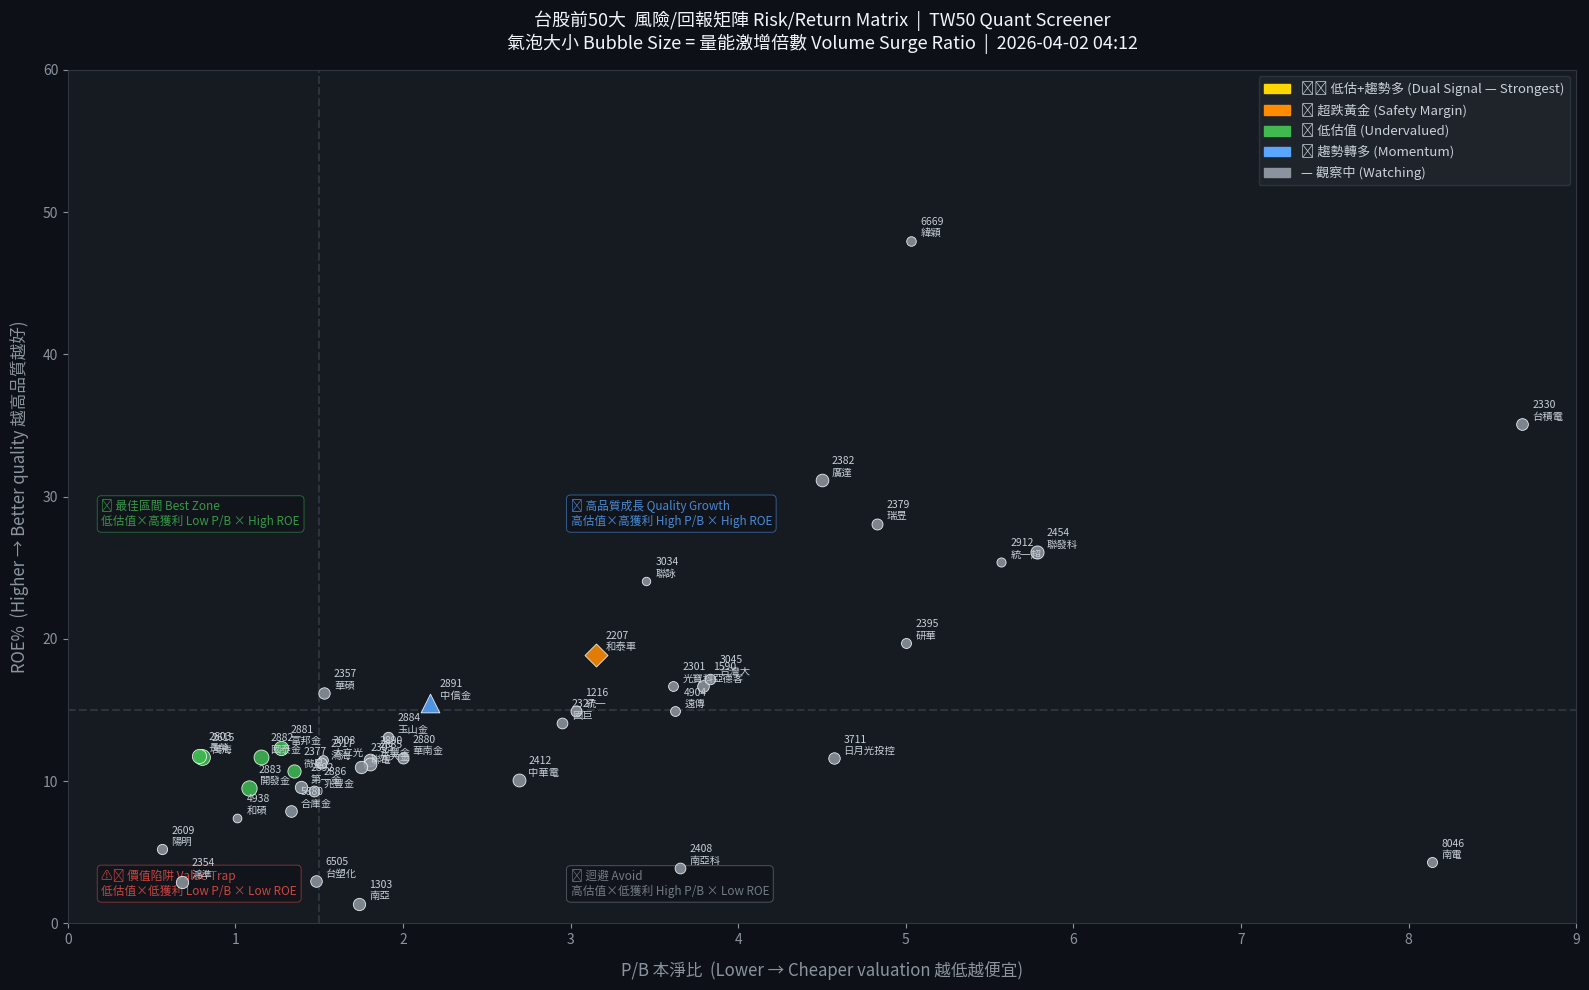


📊 矩陣圖已儲存 | Matrix saved as: tw50_matrix.png


In [12]:
def plot_risk_reward_matrix(df: pd.DataFrame, figsize=(16, 10)):
    """
    繪製 P/B vs ROE 風險/回報矩陣圖
    Plot P/B vs ROE Risk/Return Matrix Chart
    """
    plot_df = df.dropna(subset=["本淨比 P/B", "ROE%"]).copy()

    if len(plot_df) == 0:
        print("⚠️  無足夠數據繪圖 | Insufficient data for plotting")
        return

    # ── 圖表設定 | Figure Setup ──────────────────────────────────────
    fig, ax = plt.subplots(figsize=figsize, facecolor='#0D1117')
    ax.set_facecolor('#161B22')

    # ── 象限分割線 | Quadrant Dividers ──────────────────────────────
    ax.axvline(x=1.5, color='#30363D', linewidth=1.5, linestyle='--', alpha=0.9, zorder=1)
    ax.axhline(y=15,  color='#30363D', linewidth=1.5, linestyle='--', alpha=0.9, zorder=1)

    # 象限標籤 | Quadrant Labels
    quad_labels = [
        (0.2, 28, '🏆 最佳區間 Best Zone\n低估值×高獲利 Low P/B × High ROE', '#3FB950'),
        (3.0, 28, '✨ 高品質成長 Quality Growth\n高估值×高獲利 High P/B × High ROE', '#58A6FF'),
        (0.2, 2,  '⚠️ 價值陷阱 Value Trap\n低估值×低獲利 Low P/B × Low ROE', '#F85149'),
        (3.0, 2,  '🚫 迴避 Avoid\n高估值×低獲利 High P/B × Low ROE', '#8B949E'),
    ]
    for x, y, txt, col in quad_labels:
        ax.text(x, y, txt, fontsize=8.5, color=col, alpha=0.8, zorder=2,
                bbox=dict(boxstyle='round,pad=0.35', facecolor='#0D1117', alpha=0.55,
                          edgecolor=col, linewidth=0.6))

    # ── 散點繪製 | Scatter Plots ─────────────────────────────────────
    def get_style(label):
        """根據信號標籤決定顏色、形狀、基礎大小 | Style by signal label"""
        if "被低估" in str(label) and "趨勢轉多" in str(label):
            return '#FFD700', '*', 250   # 金色星形：雙重最強訊號
        if "超跌黃金" in str(label):
            return '#FF8C00', 'D', 140   # 橘色菱形
        if "被低估" in str(label):
            return '#3FB950', 'o', 120   # 綠色圓
        if "趨勢轉多" in str(label):
            return '#58A6FF', '^', 120   # 藍色三角
        return '#8B949E', 'o', 70        # 灰色：觀察中

    for _, row in plot_df.iterrows():
        pb    = row["本淨比 P/B"]
        roe   = row["ROE%"]
        vol   = min(row.get("量能倍數 Vol.Ratio", 1.0), 4.0)
        color, marker, base_s = get_style(row.get("信號標籤 Signal", ""))
        ax.scatter(pb, roe,
                   c=color, marker=marker, s=base_s * vol,
                   alpha=0.88, edgecolors='white', linewidth=0.6, zorder=5)

        # 股票標籤 | Stock Label
        short_name = row["名稱 Name"].split(" / ")[0]  # 只顯示中文名 Show Chinese only
        ax.annotate(
            f"{row['代號 Ticker']}\n{short_name}",
            (pb, roe),
            textcoords="offset points", xytext=(7, 3),
            fontsize=7.5, color='#C9D1D9', zorder=6
        )

    # ── 圖例 | Legend ─────────────────────────────────────────────────
    legend_items = [
        mpatches.Patch(color='#FFD700', label='💎🚀 低估+趨勢多 (Dual Signal — Strongest)'),
        mpatches.Patch(color='#FF8C00', label='⭐ 超跌黃金 (Safety Margin)'),
        mpatches.Patch(color='#3FB950', label='💎 低估值 (Undervalued)'),
        mpatches.Patch(color='#58A6FF', label='🚀 趨勢轉多 (Momentum)'),
        mpatches.Patch(color='#8B949E', label='— 觀察中 (Watching)'),
    ]
    ax.legend(handles=legend_items, loc='upper right',
              facecolor='#21262D', edgecolor='#30363D',
              labelcolor='#C9D1D9', fontsize=9.5, framealpha=0.9)

    # ── 軸線標題 | Axis Labels & Title ───────────────────────────────
    ax.set_xlabel("P/B 本淨比  (Lower → Cheaper valuation 越低越便宜)",
                  color='#8B949E', fontsize=12, labelpad=10)
    ax.set_ylabel("ROE%  (Higher → Better quality 越高品質越好)",
                  color='#8B949E', fontsize=12, labelpad=10)
    ax.set_title(
        f"台股前50大  風險/回報矩陣 Risk/Return Matrix  |  TW50 Quant Screener\n"
        f"氣泡大小 Bubble Size = 量能激增倍數 Volume Surge Ratio  |  "
        f"{datetime.now().strftime('%Y-%m-%d %H:%M')}",
        color='#F0F6FC', fontsize=13, pad=15
    )

    ax.tick_params(colors='#8B949E')
    for spine in ax.spines.values():
        spine.set_color('#30363D')

    # 動態設定軸範圍 | Dynamic axis limits
    x_max = min(float(plot_df["本淨比 P/B"].max()) * 1.25, 9.0)
    y_max = min(float(plot_df["ROE%"].max()) * 1.2, 60.0)
    ax.set_xlim(0, x_max)
    ax.set_ylim(0, y_max)

    plt.tight_layout()
    plt.savefig("tw50_matrix.png", dpi=150, bbox_inches='tight',
                facecolor='#0D1117', edgecolor='none')
    plt.show()
    print("\n📊 矩陣圖已儲存 | Matrix saved as: tw50_matrix.png")


plot_risk_reward_matrix(df)


## 🧭 Step 9: 探勘結論解讀指南 | Interpretation Guide

**中文說明：** 自動生成當日「最強關注清單」與解讀說明。  
**English:** Auto-generate today's "top watchlist" with interpretation guidance.


In [13]:
def print_interpretation(df: pd.DataFrame):
    """列印完整解讀指南 | Print full interpretation guide"""

    undervalued = df[df["信號標籤 Signal"].str.contains("被低估", na=False)]
    momentum    = df[df["信號標籤 Signal"].str.contains("趨勢轉多", na=False)]
    golden      = df[df["信號標籤 Signal"].str.contains("超跌黃金", na=False)]
    dual        = df[
        df["信號標籤 Signal"].str.contains("被低估", na=False) &
        df["信號標籤 Signal"].str.contains("趨勢轉多", na=False)
    ]

    print("\n" + "╔" + "═"*70 + "╗")
    print("║  🧭  今日選股探勘結論總結 | Today's Screening Summary              ║")
    print("╠" + "═"*70 + "╣")

    # 信號統計
    signals_data = [
        ("💎 被低估 Undervalued",      len(undervalued), "PE<15 & PB<1.5 & ROE>8%"),
        ("🚀 趨勢轉多 Momentum",        len(momentum),    "穿越MA20 & 量能>1.2x"),
        ("⭐ 超跌黃金 Safety Margin",   len(golden),      "低於年線>10% & ROE>15%"),
        ("🔥 雙重確認 Dual Signal",     len(dual),        "最強訊號 Strongest signal"),
    ]
    for label, count, crit in signals_data:
        bar = "█" * count + "░" * max(0, 10-count)
        line = f"  {label:<30} [{bar}] {count:2d} 檔"
        print(f"║  {line:<70}  ║")

    print("╠" + "═"*70 + "╣")
    print("║                                                                      ║")
    print("║  📖 如何解讀數據 | HOW TO INTERPRET THE DATA                        ║")
    print("║                                                                      ║")
    print("║  ① 雙重確認（最強） Dual Confirmation (Strongest)                   ║")
    print("║     條件 Criteria: 💎 被低估 + 🚀 趨勢轉多 同時出現                  ║")
    print("║     意義 Meaning : 估值便宜 × 資金介入 = 勝率最高的買點              ║")
    print("║     Cheap valuation × Capital inflow = Highest-probability entry     ║")
    print("║                                                                      ║")
    print("║  ② 超跌反轉 Oversold Reversal                                       ║")
    print("║     條件 Criteria: ROE>15% 但股價低於年線 > 20%                     ║")
    print("║     意義 Meaning : 市場情緒過度悲觀，等量能放大時介入                ║")
    print("║     Market over-pessimistic; enter when volume starts expanding      ║")
    print("║                                                                      ║")
    print("║  ③ 量能爆發穿線 Volume Breakout Cross                               ║")
    print("║     條件 Criteria: 量能倍數>2.0 且剛穿越 MA20                       ║")
    print("║     意義 Meaning : 大資金進場確認，短線動能強勁                      ║")
    print("║     Large capital entering; strong short-term momentum               ║")
    print("║                                                                      ║")
    print("║  ⚠️  必須排除 MUST EXCLUDE (Value Traps 價值陷阱):                  ║")
    print("║     PE < 10 但 ROE < 5%  → 公司正在衰退 Company declining           ║")
    print("║     PB < 1  但 Op.Margin < 3% → 本業無法獲利 Core biz not viable    ║")
    print("║                                                                      ║")
    print("╠" + "═"*70 + "╣")

    # 今日最強標的
    top5 = df.head(5)
    print("║  🏆 今日綜合得分前5名 | Today's Top 5 by Composite Score            ║")
    for rank, (_, row) in enumerate(top5.iterrows(), 1):
        ticker = row["代號 Ticker"]
        name   = row["名稱 Name"].split(" / ")[0]  # 中文名
        score  = row["綜合得分 Score"]
        signal = row["信號標籤 Signal"].replace("— 觀察中 Watching", "—")
        line   = f"  #{rank}  {ticker} {name:<6}  得分 Score:{score:5.1f}  {signal}"
        print(f"║  {line:<70}  ║")

    print("╚" + "═"*70 + "╝")
    print()
    print("⚠️  免責聲明 Disclaimer: 本系統僅供量化研究參考，不構成投資建議。")
    print("   This system is for quantitative research only, not investment advice.")


print_interpretation(df)



╔══════════════════════════════════════════════════════════════════════╗
║  🧭  今日選股探勘結論總結 | Today's Screening Summary              ║
╠══════════════════════════════════════════════════════════════════════╣
║    💎 被低估 Undervalued              [██████░░░░]  6 檔                      ║
║    🚀 趨勢轉多 Momentum                [█░░░░░░░░░]  1 檔                      ║
║    ⭐ 超跌黃金 Safety Margin           [█░░░░░░░░░]  1 檔                      ║
║    🔥 雙重確認 Dual Signal             [░░░░░░░░░░]  0 檔                      ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  📖 如何解讀數據 | HOW TO INTERPRET THE DATA                        ║
║                                                                      ║
║  ① 雙重確認（最強） Dual Confirmation (Strongest)                   ║
║     條件 Criteria: 💎 被低估 + 🚀 趨勢轉多 同時出現                  ║
║     意義 Meaning : 估值便宜 × 資金介入 = 勝率最高的買點              ║
║     Cheap valuation ×

## 💾 Step 10: 匯出報表 | Export Report

**中文說明：** 將完整分析結果匯出為 CSV，可用 Excel 開啟進行進一步分析。在 Google Colab 中會自動下載。  
**English:** Export full analysis results to CSV (Excel-compatible). In Google Colab, the file will auto-download.


In [14]:
# ── 匯出 CSV | Export to CSV ──────────────────────────────────────
timestamp  = datetime.now().strftime('%Y%m%d_%H%M')
csv_path   = f"tw50_report_{timestamp}.csv"

# utf-8-sig 確保 Excel 開啟中文不亂碼 | utf-8-sig for correct Chinese display in Excel
df.to_csv(csv_path, index=True, encoding='utf-8-sig')
print(f"💾 報表已儲存 | Report saved: {csv_path}")

# ── Google Colab 自動下載 | Auto-download in Google Colab ─────────
try:
    from google.colab import files
    files.download(csv_path)
    files.download("tw50_matrix.png")
    print("📥 Colab 自動下載中 | Colab downloading files...")
except ImportError:
    print("💡 本機模式：檔案已儲存在當前目錄 | Local mode: files saved in current directory")

# ── 最終統計摘要 | Final Summary Stats ───────────────────────────
print("\n" + "─"*50)
print("📊 最終分析摘要 | Final Analysis Summary")
print("─"*50)
print(f"  分析股票總數 Total stocks analyzed:  {len(df)}")
print(f"  觸發任一信號 Any signal triggered:   "
      f"{len(df[df['信號標籤 Signal'] != '— 觀察中 Watching'])}")
print(f"  💎 被低估 Undervalued:               "
      f"{len(df[df['信號標籤 Signal'].str.contains('被低估', na=False)])}")
print(f"  🚀 趨勢轉多 Momentum:                "
      f"{len(df[df['信號標籤 Signal'].str.contains('趨勢轉多', na=False)])}")
print(f"  ⭐ 超跌黃金 Safety Margin:           "
      f"{len(df[df['信號標籤 Signal'].str.contains('超跌黃金', na=False)])}")
print(f"  🔥 雙重確認 Dual Signal:             "
      f"{len(df[df['信號標籤 Signal'].str.contains('被低估', na=False) & df['信號標籤 Signal'].str.contains('趨勢轉多', na=False)])}")
print("─"*50)
print("\n✅ 全部分析完成！| All analysis complete!")
print("   下次執行直接從頭 Run 即可自動更新最新數據")
print("   Just re-run all cells next time to get fresh data automatically")


💾 報表已儲存 | Report saved: tw50_report_20260402_0413.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 Colab 自動下載中 | Colab downloading files...

──────────────────────────────────────────────────
📊 最終分析摘要 | Final Analysis Summary
──────────────────────────────────────────────────
  分析股票總數 Total stocks analyzed:  48
  觸發任一信號 Any signal triggered:   8
  💎 被低估 Undervalued:               6
  🚀 趨勢轉多 Momentum:                1
  ⭐ 超跌黃金 Safety Margin:           1
  🔥 雙重確認 Dual Signal:             0
──────────────────────────────────────────────────

✅ 全部分析完成！| All analysis complete!
   下次執行直接從頭 Run 即可自動更新最新數據
   Just re-run all cells next time to get fresh data automatically
